# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [1]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install "numpy<2.0"

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch-fidelity

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install torchmetrics[image]

zsh:1: no matches found: torchmetrics[image]
Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install torchmetrics

In [1]:
!pip install --upgrade torch torchvision torchmetrics numpy

  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_x86_64.whl (6.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.5.0 requires daal==2021.4.0, which is not installed.
rf-groundingdino 0.1.2 requires transformers, which is not installed.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
matplotlib 3.8.2 requires numpy<2,>=1.21, but you have numpy 2.0.2 which is incompatible.
numba 0.56.4 requires numpy<1.24,>=1.18, but you have numpy 2.0.2 which is incompatible.
scipy 1.10.1 requires numpy<1.27.0,>=1.19.5, but you have numpy 2.0.2 which is incompatible.
supervision 0.16.0 requires num

In [2]:
pip install "numpy<2.0"

  Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl (20.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.5.0 requires daal==2021.4.0, which is not installed.
rf-groundingdino 0.1.2 requires transformers, which is not installed.
numba 0.56.4 requires numpy<1.24,>=1.18, but you have numpy 1.26.4 which is incompatible.
tb-nightly 2.16.0a20231109 requires grpcio>=1.48.2, but you have grpcio 1.42.0 which is incompatible.
tensorboard 2.14.1 requires grpcio>=1.48.2, but you have grpcio 1.42.0 which is incompatible.
tensorflow 2.14.0 requires ml-dtypes==0.2.0, but you have ml-dtypes 0.3.1 which is incompatible.
Note: you m

In [3]:
pip install --upgrade matplotlib scipy torch torchvision torchmetrics

  Using cached matplotlib-3.9.4-cp39-cp39-macosx_10_12_x86_64.whl.metadata (11 kB)
Using cached matplotlib-3.9.4-cp39-cp39-macosx_10_12_x86_64.whl (7.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.4/39.4 MB 10.0 MB/s  0:00:03m0:00:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.10.1
    Uninstalling scipy-1.10.1:━━━━━━━━━━━━━━━━━━ 0/2 [scipy]
      Successfully uninstalled scipy-1.10.1━ 0/2 [scipy]
  Attempting uninstall: matplotlib━━━━━━━━━━━━━━ 0/2 [scipy]
    Found existing installation: matplotlib 3.8.20/2 [scipy]
    Uninstalling matplotlib-3.8.2:━━━━━━━━━━ 0/2 [scipy]
      Successfully uninstalled matplotlib-3.8.2━━━━━━━━━━━━━━━━━━━ 1/2 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [matplotlib]2 [matplotlib]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rf-groundingdino 0.1.2 requires transformers, wh

In [3]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from torchmetrics.image.kid import KernelInceptionDistance
from torchmetrics.image.fid import FrechetInceptionDistance
import torch.nn as nn
import torch.optim as optim
import torchvision

In [4]:
from pathlib import Path
import sys
import random
import numpy as np
import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Caminho base (ajusta conforme a pasta onde corres o notebook)
PROJECT_ROOT = Path('.').resolve().parent 

print("Pastas encontradas em PROJECT_ROOT:")
print([p.name for p in PROJECT_ROOT.iterdir() if p.is_dir()])

# Ajuste aqui se o nome for diferente (ex: 'artbench-10' ou 'ArtBench')
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10' 
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'


if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('SCRIPTS_DIR:', SCRIPTS_DIR)
print('Conteúdo:', list(SCRIPTS_DIR.iterdir()))

from artbench_local_dataset import load_kaggle_artbench10_splits

# Verifica se as pastas existem
if not KAGGLE_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Verifica se estás na pasta certa ou ajusta PROJECT_ROOT.'
    )

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)

Pastas encontradas em PROJECT_ROOT:
['ArtBench-10', 'student_start_pack', 'scripts']
SCRIPTS_DIR: /Users/diana/Desktop/MIACD/1 ano/2 semestre/IAG/projeto_iag/TP1-alunos-src-only/scripts
Conteúdo: [PosixPath('/Users/diana/Desktop/MIACD/1 ano/2 semestre/IAG/projeto_iag/TP1-alunos-src-only/scripts/.DS_Store'), PosixPath('/Users/diana/Desktop/MIACD/1 ano/2 semestre/IAG/projeto_iag/TP1-alunos-src-only/scripts/__pycache__'), PosixPath('/Users/diana/Desktop/MIACD/1 ano/2 semestre/IAG/projeto_iag/TP1-alunos-src-only/scripts/artbench_local_dataset.py')]
PROJECT_ROOT = /Users/diana/Desktop/MIACD/1 ano/2 semestre/IAG/projeto_iag/TP1-alunos-src-only
KAGGLE_ROOT  = /Users/diana/Desktop/MIACD/1 ano/2 semestre/IAG/projeto_iag/TP1-alunos-src-only/ArtBench-10


In [ ]:
import os
print(os.getcwd())

/Users/diana/Desktop/MIACD/1 ano/2 semestre/IAG/projeto_iag/TP1-alunos-src-only/student_start_pack


In [5]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='/Users/diana/Desktop/MIACD/1 ano/2 semestre/IAG/projeto_iag/TP1-alunos-src-only/ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [6]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [7]:
IMAGE_SIZE = 32
BATCH_SIZE = 32
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 1563


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [8]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 313


## Visualize a sample grid

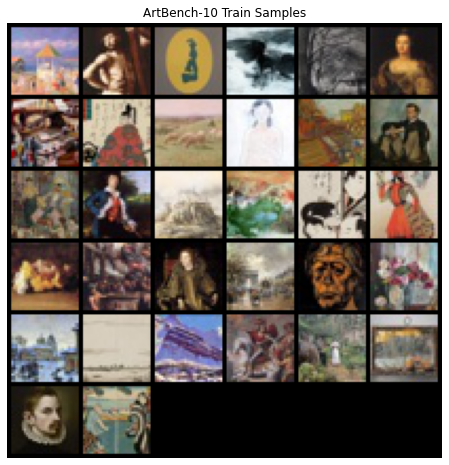

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e']


In [9]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [10]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data/train_subset/images
Metadata CSV: exported_data/train_subset/metadata.csv


GANS

In [11]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) #ficar normalizado entre -1 e 1
])

In [12]:
def get_fixed_real_samples(full_dataset, n_samples=5000, seed=42):
    """
    Seleciona 5000 imagens reais do dataset completo para avaliação.
    Nota: O transform do full_dataset deve incluir Normalize((0.5,), (0.5,))
    para bater com o Tanh() da tua GAN.
    """
    g = np.random.RandomState(seed)
    indices = g.choice(len(full_dataset), n_samples, replace=False)
    
    subset = Subset(full_dataset, indices)
    loader = DataLoader(subset, batch_size=100, shuffle=False)
    
    real_images = []
    for batch, _, _ in loader:
        real_images.append(batch)
    
    return torch.cat(real_images, dim=0) # [5000, 3, 32, 32]


real_samples_eval = get_fixed_real_samples(train_ds) 
print(f"Conjunto de avaliação real pronto: {real_samples_eval.shape}")

Conjunto de avaliação real pronto: torch.Size([5000, 3, 32, 32])


In [13]:
def compute_metrics_protocol(generator, real_images, latent_dim, device, n_samples=5000):
    """
    Executa o protocolo: 5000 fake vs 5000 real.
    Calcula FID e KID (média/std de 50 subsets de 100).
    """
    generator.eval()
    kid_metric = KernelInceptionDistance(subset_size=100, subsets=50).to(device)
    
    # 1. Gerar 5000 imagens fake
    fakes = []
    with torch.no_grad():
        for _ in range(n_samples // 100): # batches de 100
            z = torch.randn(100, latent_dim, device=device)
            samples = generator(z)
            fakes.append(samples)
    fake_images = torch.cat(fakes, dim=0)

    # 2. Atualizar métrica (torchmetrics lida com os subsets internamente se configurada)
    # Importante: converter para uint8 [0, 255] se a biblioteca exigir, 
    # ou garantir que a escala está correta.
    
    #FID/KID esperam valores [0, 255] tipo Byte
    real_imgs_uint8 = ((real_images + 1) * 127.5).clamp(0, 255).to(torch.uint8).to(device)
    fake_imgs_uint8 = ((fake_images + 1) * 127.5).clamp(0, 255).to(torch.uint8).to(device)

    kid_metric.update(real_imgs_uint8, real=True)
    kid_metric.update(fake_imgs_uint8, real=False)
    
    kid_mean, kid_std = kid_metric.compute()
    
    return kid_mean.item(), kid_std.item()

In [14]:
latent_dim = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
num_epochs = 10  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [1]:
import torch
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"Nome da GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Nenhuma'}")

CUDA disponível: False
Nome da GPU: Nenhuma


In [15]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 8 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (128, 8, 8)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128, momentum=0.78),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.78),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ZeroPad2d((0, 1, 0, 1)),
            nn.BatchNorm2d(64, momentum=0.82),
            nn.LeakyReLU(0.25),
            nn.Dropout(0.25),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128, momentum=0.82),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256, momentum=0.8),
            nn.LeakyReLU(0.25),
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(256 * 5 * 5, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        validity = self.model(img)
        return validity

In [16]:
def run_evaluation_protocol(generator, real_samples, latent_dim, n_samples=5000):
    generator.eval()
    
    # Inicializar as duas métricas obrigatórias [cite: 68]
    fid_metric = FrechetInceptionDistance(feature=64).to(device) # feature=64 para ser mais rápido, ou 2048 para rigor total
    kid_metric = KernelInceptionDistance(subset_size=100, subsets=50).to(device)
    
    fakes = []
    with torch.no_grad():
        for _ in range(n_samples // 100):
            z = torch.randn(100, latent_dim, device=device)
            fakes.append(generator(z))
    
    fake_samples = torch.cat(fakes, dim=0)

    # Conversão para uint8 [0, 255] conforme exigido para estas métricas
    real_uint8 = ((real_samples + 1) * 127.5).clamp(0, 255).to(torch.uint8).to(device)
    fake_uint8 = ((fake_samples + 1) * 127.5).clamp(0, 255).to(torch.uint8).to(device)

    # FID: Calculado sobre o conjunto total de 5000 imagens 
    fid_metric.update(real_uint8, real=True)
    fid_metric.update(fake_uint8, real=False)
    fid_value = fid_metric.compute()

    # KID: Calculado com 50 subsets de 100 [cite: 77, 78]
    kid_metric.update(real_uint8, real=True)
    kid_metric.update(fake_uint8, real=False)
    kid_mean, kid_std = kid_metric.compute()
    
    return fid_value.item(), kid_mean.item(), kid_std.item()

In [ ]:
#guardar os dados caso o computador bloquuei de novo
def save_result_to_csv(filename, data):
    file_exists = Path(filename).exists()
    with open(filename, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=data.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(data)

: 

In [ ]:
# --- CONFIGURAÇÃO DE TESTE RÁPIDO ---
# Para o teste final do relatório, usa as 10 seeds e mais épocas
from librosa import cite


seeds = [42] 
RESULTS_FILE = "resultados_42seeds_10epochs.csv"
# ------------------------------------

all_fids = []
all_kids_mean = []

# Nota: Garante que real_samples_eval e run_evaluation_protocol já foram definidos
for run_seed in seeds:
    print(f"\n>>> A INICIAR RUN (Seed: {run_seed}) <<<")
    torch.manual_seed(run_seed)
    np.random.seed(run_seed)
    random.seed(run_seed)
    
    # Inicialização dos modelos
    generator = Generator(latent_dim).to(device)
    discriminator = Discriminator().to(device)
    
    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
    
    adversarial_loss = nn.BCELoss()

    for epoch in range(num_epochs):
        generator.train()
        for i, batch in enumerate(train_loader_from_csv):
            # 1. Preparação dos dados
            real_images = batch[0].to(device)
            batch_size = real_images.size(0)
            
            valid = torch.ones(batch_size, 1, device=device)
            fake = torch.zeros(batch_size, 1, device=device)

            # 2. Treino do Discriminador
            optimizer_D.zero_grad()
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z)

            real_loss = adversarial_loss(discriminator(real_images), valid)
            fake_loss = adversarial_loss(discriminator(fake_images.detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            
            d_loss.backward()
            optimizer_D.step()

            # 3. Treino do Gerador
            optimizer_G.zero_grad()
            gen_images = generator(z)
            g_loss = adversarial_loss(discriminator(gen_images), valid)
            
            g_loss.backward()
            optimizer_G.step()

            if (i + 1) % 50 == 0:
                print(f"[Epoch {epoch+1}/{num_epochs}] [Batch {i+1}/{len(train_loader_from_csv)}] "
                      f"D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

    # --- AVALIAÇÃO OBRIGATÓRIA (FID e KID) ---
    print(f"--- A calcular métricas para a Seed {run_seed} ---")
    fid, k_mean, k_std = run_evaluation_protocol(generator, real_samples_eval, latent_dim)
    
    # --- GUARDAR OS DADOS NO DISCO (Segurança contra crash) ---
    res = {
        'seed': run_seed,
        'fid': fid,
        'kid_mean': k_mean,
        'kid_std': k_std,
        'epochs': num_epochs,
        'lr': lr
    }
    save_result_to_csv(RESULTS_FILE, res)
    print(f"✅ Resultados da Seed {run_seed} guardados com sucesso em {RESULTS_FILE}")
    
    all_fids.append(fid)
    all_kids_mean.append(k_mean)
    
    print(f"RESULTADOS SEED {run_seed}: FID: {fid:.4f} | KID: {k_mean:.5f} (±{k_std:.5f})")

# --- RESUMO FINAL ---
print("\n" + "="*50)
print("RESUMO FINAL (Para o Relatório LNCS)")
if len(all_fids) > 0:
    print(f"FID FINAL: {np.mean(all_fids):.4f} ± {np.std(all_fids):.4f}")
    print(f"KID FINAL: {np.mean(all_kids_mean):.5f} ± {np.std(all_kids_mean):.5f}")
print("="*50)


>>> A INICIAR RUN (Seed: 42) <<<
[Epoch 1/10] [Batch 50/313] D loss: 0.4507 | G loss: 1.8712
[Epoch 1/10] [Batch 100/313] D loss: 0.7615 | G loss: 0.7190
[Epoch 1/10] [Batch 150/313] D loss: 0.8069 | G loss: 1.0738
[Epoch 1/10] [Batch 200/313] D loss: 0.6318 | G loss: 0.9685
[Epoch 1/10] [Batch 250/313] D loss: 0.5925 | G loss: 1.2369
[Epoch 1/10] [Batch 300/313] D loss: 0.5580 | G loss: 1.3280
[Epoch 2/10] [Batch 50/313] D loss: 0.6017 | G loss: 1.0555
[Epoch 2/10] [Batch 100/313] D loss: 0.7417 | G loss: 0.8545
[Epoch 2/10] [Batch 150/313] D loss: 0.6926 | G loss: 0.9314
[Epoch 2/10] [Batch 200/313] D loss: 0.7350 | G loss: 0.8115
[Epoch 2/10] [Batch 250/313] D loss: 0.7189 | G loss: 0.9896
[Epoch 2/10] [Batch 300/313] D loss: 0.6209 | G loss: 1.1873
[Epoch 3/10] [Batch 50/313] D loss: 0.7912 | G loss: 0.7248
[Epoch 3/10] [Batch 100/313] D loss: 0.7649 | G loss: 0.8961
[Epoch 3/10] [Batch 150/313] D loss: 0.5823 | G loss: 1.1294
[Epoch 3/10] [Batch 200/313] D loss: 0.8213 | G loss: 

/Users/diana/opt/anaconda3/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


In [ ]:
latent_dim = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
num_epochs = 20  


In [ ]:
# --- CONFIGURAÇÃO DE TESTE RÁPIDO ---
# Para o teste final do relatório, usa as 10 seeds e mais épocas
from librosa import cite


seeds = [42] 
RESULTS_FILE = "resultados_42seeds_20epochs.csv"
# ------------------------------------

all_fids = []
all_kids_mean = []

# Nota: Garante que real_samples_eval e run_evaluation_protocol já foram definidos
for run_seed in seeds:
    print(f"\n>>> A INICIAR RUN (Seed: {run_seed}) <<<")
    torch.manual_seed(run_seed)
    np.random.seed(run_seed)
    random.seed(run_seed)
    
    # Inicialização dos modelos
    generator = Generator(latent_dim).to(device)
    discriminator = Discriminator().to(device)
    
    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
    
    adversarial_loss = nn.BCELoss()

    for epoch in range(num_epochs):
        generator.train()
        for i, batch in enumerate(train_loader_from_csv):
            # 1. Preparação dos dados
            real_images = batch[0].to(device)
            batch_size = real_images.size(0)
            
            valid = torch.ones(batch_size, 1, device=device)
            fake = torch.zeros(batch_size, 1, device=device)

            # 2. Treino do Discriminador
            optimizer_D.zero_grad()
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z)

            real_loss = adversarial_loss(discriminator(real_images), valid)
            fake_loss = adversarial_loss(discriminator(fake_images.detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            
            d_loss.backward()
            optimizer_D.step()

            # 3. Treino do Gerador
            optimizer_G.zero_grad()
            gen_images = generator(z)
            g_loss = adversarial_loss(discriminator(gen_images), valid)
            
            g_loss.backward()
            optimizer_G.step()

            if (i + 1) % 50 == 0:
                print(f"[Epoch {epoch+1}/{num_epochs}] [Batch {i+1}/{len(train_loader_from_csv)}] "
                      f"D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

    # --- AVALIAÇÃO OBRIGATÓRIA (FID e KID) ---
    print(f"--- A calcular métricas para a Seed {run_seed} ---")
    fid, k_mean, k_std = run_evaluation_protocol(generator, real_samples_eval, latent_dim)
    
    # --- GUARDAR OS DADOS NO DISCO (Segurança contra crash) ---
    res = {
        'seed': run_seed,
        'fid': fid,
        'kid_mean': k_mean,
        'kid_std': k_std,
        'epochs': num_epochs,
        'lr': lr
    }
    save_result_to_csv(RESULTS_FILE, res)
    print(f"✅ Resultados da Seed {run_seed} guardados com sucesso em {RESULTS_FILE}")
    
    all_fids.append(fid)
    all_kids_mean.append(k_mean)
    
    print(f"RESULTADOS SEED {run_seed}: FID: {fid:.4f} | KID: {k_mean:.5f} (±{k_std:.5f})")

# --- RESUMO FINAL ---
print("\n" + "="*50)
print("RESUMO FINAL (Para o Relatório LNCS)")
if len(all_fids) > 0:
    print(f"FID FINAL: {np.mean(all_fids):.4f} ± {np.std(all_fids):.4f}")
    print(f"KID FINAL: {np.mean(all_kids_mean):.5f} ± {np.std(all_kids_mean):.5f}")
print("="*50)

In [ ]:
latent_dim = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
num_epochs = 50  


In [ ]:
# --- CONFIGURAÇÃO DE TESTE RÁPIDO ---
# Para o teste final do relatório, usa as 10 seeds e mais épocas
from librosa import cite


seeds = [42] 
RESULTS_FILE = "resultados_42seeds_50epochs.csv"
# ------------------------------------

all_fids = []
all_kids_mean = []

# Nota: Garante que real_samples_eval e run_evaluation_protocol já foram definidos
for run_seed in seeds:
    print(f"\n>>> A INICIAR RUN (Seed: {run_seed}) <<<")
    torch.manual_seed(run_seed)
    np.random.seed(run_seed)
    random.seed(run_seed)
    
    # Inicialização dos modelos
    generator = Generator(latent_dim).to(device)
    discriminator = Discriminator().to(device)
    
    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
    
    adversarial_loss = nn.BCELoss()

    for epoch in range(num_epochs):
        generator.train()
        for i, batch in enumerate(train_loader_from_csv):
            # 1. Preparação dos dados
            real_images = batch[0].to(device)
            batch_size = real_images.size(0)
            
            valid = torch.ones(batch_size, 1, device=device)
            fake = torch.zeros(batch_size, 1, device=device)

            # 2. Treino do Discriminador
            optimizer_D.zero_grad()
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z)

            real_loss = adversarial_loss(discriminator(real_images), valid)
            fake_loss = adversarial_loss(discriminator(fake_images.detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            
            d_loss.backward()
            optimizer_D.step()

            # 3. Treino do Gerador
            optimizer_G.zero_grad()
            gen_images = generator(z)
            g_loss = adversarial_loss(discriminator(gen_images), valid)
            
            g_loss.backward()
            optimizer_G.step()

            if (i + 1) % 50 == 0:
                print(f"[Epoch {epoch+1}/{num_epochs}] [Batch {i+1}/{len(train_loader_from_csv)}] "
                      f"D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

    # --- AVALIAÇÃO OBRIGATÓRIA (FID e KID) ---
    print(f"--- A calcular métricas para a Seed {run_seed} ---")
    fid, k_mean, k_std = run_evaluation_protocol(generator, real_samples_eval, latent_dim)
    
    # --- GUARDAR OS DADOS NO DISCO (Segurança contra crash) ---
    res = {
        'seed': run_seed,
        'fid': fid,
        'kid_mean': k_mean,
        'kid_std': k_std,
        'epochs': num_epochs,
        'lr': lr
    }
    save_result_to_csv(RESULTS_FILE, res)
    print(f"✅ Resultados da Seed {run_seed} guardados com sucesso em {RESULTS_FILE}")
    
    all_fids.append(fid)
    all_kids_mean.append(k_mean)
    
    print(f"RESULTADOS SEED {run_seed}: FID: {fid:.4f} | KID: {k_mean:.5f} (±{k_std:.5f})")

# --- RESUMO FINAL ---
print("\n" + "="*50)
print("RESUMO FINAL (Para o Relatório LNCS)")
if len(all_fids) > 0:
    print(f"FID FINAL: {np.mean(all_fids):.4f} ± {np.std(all_fids):.4f}")
    print(f"KID FINAL: {np.mean(all_kids_mean):.5f} ± {np.std(all_kids_mean):.5f}")
print("="*50)

3 seeds

In [ ]:
# --- CONFIGURAÇÃO ---
seeds = [42, 123, 456] 
num_epochs = 20 # Ou as 10 que estavas a usar, mas 20 é melhor para estabilidade
RESULTS_FILE = "resultados_estabilidade_3seeds.csv"
# --------------------

all_fids = []
all_kids_mean = []

for run_seed in seeds:
    print(f"\n>>> A INICIAR RUN (Seed: {run_seed}) <<<")
    torch.manual_seed(run_seed)
    np.random.seed(run_seed)
    random.seed(run_seed)
    
    generator = Generator(latent_dim).to(device)
    discriminator = Discriminator().to(device)
    
    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
    
    adversarial_loss = nn.BCELoss()

    for epoch in range(num_epochs):
        generator.train()
        for i, batch in enumerate(train_loader_from_csv):
            real_images = batch[0].to(device)
            batch_size = real_images.size(0)
            
            valid = torch.ones(batch_size, 1, device=device)
            fake = torch.zeros(batch_size, 1, device=device)

            optimizer_D.zero_grad()
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z)
            d_loss = (adversarial_loss(discriminator(real_images), valid) + 
                      adversarial_loss(discriminator(fake_images.detach()), fake)) / 2
            d_loss.backward()
            optimizer_D.step()

            optimizer_G.zero_grad()
            g_loss = adversarial_loss(discriminator(generator(z)), valid)
            g_loss.backward()
            optimizer_G.step()

            if (i + 1) % 50 == 0:
                print(f"[Epoch {epoch+1}/{num_epochs}] [Seed {run_seed}] D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

    # --- AVALIAÇÃO ---
    print(f"--- A calcular métricas para a Seed {run_seed} ---")
    fid, k_mean, k_std = run_evaluation_protocol(generator, real_samples_eval, latent_dim)
    
    # GUARDAR NO DISCO
    res = {
        'seed': run_seed,
        'fid': fid,
        'kid_mean': k_mean,
        'kid_std': k_std,
        'epochs': num_epochs,
        'lr': lr
    }
    save_result_to_csv(RESULTS_FILE, res)
    print(f"✅ Seed {run_seed} guardada em {RESULTS_FILE}")
    
    all_fids.append(fid)
    all_kids_mean.append(k_mean)

# --- RESUMO FINAL ---
print("\n" + "="*50)
print(f"RESUMO DE ESTABILIDADE ({len(seeds)} SEEDS)")
if len(all_fids) > 0:
    print(f"FID MÉDIO: {np.mean(all_fids):.4f} ± {np.std(all_fids):.4f}")
    print(f"KID MÉDIO: {np.mean(all_kids_mean):.5f} ± {np.std(all_kids_mean):.5f}")
print("="*50)